In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime
from typing import Dict, List, Optional
# Removed the import that was causing the error
# from caas_jupyter_tools import display_dataframe_to_user

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define a replacement function for display_dataframe_to_user
# This uses pandas' built-in display capabilities
def display_dataframe_to_user(df):
    # In Jupyter, returning the dataframe will display it
    return df
    # Alternatively, you could use:
    # display(df)  # If display is available in your environment

DATA_PATH = "data.csv"
CLEAN_OUT = "aqi_cleaned.csv"

In [10]:
# -------------------------
# 1) LOAD DATA ROBUSTLY
# -------------------------
def robust_read_csv(path: str) -> pd.DataFrame:
    encodings_to_try = [None, "utf-8", "utf-8-sig", "latin-1"]
    for enc in encodings_to_try:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            continue
    # fallback: engine python
    return pd.read_csv(path, engine="python", error_bad_lines=False)

df_raw = robust_read_csv(DATA_PATH).copy()

# Display basic info
shape = df_raw.shape
cols = df_raw.columns.tolist()


/var/folders/5l/1dxt54xd5dn9fs97lbsrm2ch0000gp/T/ipykernel_8670/3517511630.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, encoding=enc)


In [11]:
# -------------------------
# 2) STANDARDIZE COLUMNS
# -------------------------
def normalize_colname(c: str) -> str:
    return (
        c.strip()
         .lower()
         .replace(" ", "_")
         .replace("/", "_")
         .replace("-", "_")
         .replace(".", "")
         .replace("(", "")
         .replace(")", "")
    )

df = df_raw.copy()
df.columns = [normalize_colname(c) for c in df.columns]

# Candidate column mappings
date_candidates = ["date", "sampling_date", "datetime", "timestamp", "dt"]
state_candidates = ["state", "state_ut", "state_name", "st_name"]
city_candidates = ["city", "city_town_village_area", "location", "station", "town", "area"]

# Pollutant candidates (with aliases)
pollutant_map_candidates: Dict[str, List[str]] = {
    "pm25": ["pm2_5", "pm25", "pm2_5_ug_m3", "pm2_5ug_m3", "pm_2_5"],
    "pm10": ["pm10", "pm_10", "rspm"],
    "no2":  ["no2"],
    "so2":  ["so2"],
    "o3":   ["o3", "ozone"],
    "co":   ["co"],
    "nh3":  ["nh3"],
    "aqi":  ["aqi", "aqi_value"]
}

def pick_first_existing(cands: List[str], columns: List[str]) -> Optional[str]:
    for c in cands:
        if c in columns:
            return c
    return None

date_col = pick_first_existing(date_candidates, df.columns)
state_col = pick_first_existing(state_candidates, df.columns)
city_col  = pick_first_existing(city_candidates, df.columns)

pollutant_cols: Dict[str, Optional[str]] = {}
for canonical, cands in pollutant_map_candidates.items():
    pollutant_cols[canonical] = pick_first_existing(cands, df.columns)


In [12]:
# -------------------------
# 3) BASIC CLEANING
# -------------------------
# Strip whitespace on string columns
for c in df.select_dtypes(include=["object"]).columns:
    df[c] = df[c].astype(str).str.strip()

# Parse date if present
if date_col is not None:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    # Drop entirely invalid dates if reasonable
    if df[date_col].notna().sum() >= 0.8 * len(df):
        df = df.dropna(subset=[date_col])
else:
    # Create a placeholder for downstream logic
    df["__no_date__"] = True

# Standardize state/city casing if present
if state_col is not None:
    df[state_col] = df[state_col].str.title()
if city_col is not None:
    df[city_col] = df[city_col].str.title()

# Coerce numeric pollutants
for canon, col in pollutant_cols.items():
    if col is not None:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [13]:
# -------------------------
# 4) FEATURE ENGINEERING
# -------------------------
# Year/Month if date available
if date_col is not None:
    df["year"] = df[date_col].dt.year
    df["month"] = df[date_col].dt.month

# Create Mean_PM using whatever is present among pm25/pm10
pm25_col = pollutant_cols["pm25"]
pm10_col = pollutant_cols["pm10"]
available_pm_cols = [c for c in [pm25_col, pm10_col] if c is not None]

if available_pm_cols:
    df["mean_pm"] = df[available_pm_cols].mean(axis=1)

# If aqi missing, create proxy from available pollutants
aqi_col = pollutant_cols["aqi"]
if aqi_col is None:
    # Build AQI proxy: z-score of available pollutants averaged (simple heuristic)
    pollutant_numeric_cols = [col for key, col in pollutant_cols.items() if col is not None and key != "aqi"]
    if pollutant_numeric_cols:
        z = df[pollutant_numeric_cols].apply(lambda x: (x - x.mean())/x.std(ddof=0), axis=0)
        df["aqi_proxy"] = z.mean(axis=1)
        aqi_effective_col = "aqi_proxy"
    else:
        aqi_effective_col = None
else:
    aqi_effective_col = aqi_col


In [15]:
# -------------------------
# 5) QUICK PROFILE TABLES
# -------------------------
profile_info = {
    "rows": len(df),
    "columns": len(df.columns),
    "date_col": date_col,
    "state_col": state_col,
    "city_col": city_col,
    "aqi_col_used": aqi_effective_col,
    "available_pollutants": {k: v for k, v in pollutant_cols.items() if v is not None}
}
profile_df = pd.DataFrame.from_dict(profile_info, orient="index", columns=["value"])

# Replace the custom display function with standard display methods
# Option 1: Using display() function (works in Jupyter)
display(profile_df)  # Display the profile summary

nulls = df.isna().sum().sort_values(ascending=False).to_frame("null_count")
display(nulls)  # Display the null counts

# Option 2: Alternative if display() doesn't work
# print("Dataset — profile summary")
# print(profile_df)
# print("\nDataset — null counts")
# print(nulls)

,value
rows,435735
columns,17
date_col,date
state_col,state
city_col,location
aqi_col_used,aqi_proxy
available_pollutants,"{'pm25': 'pm2_5', 'pm10': 'rspm', 'no2': 'no2'..."


,null_count
pm2_5,426421
spm,237380
rspm,40219
mean_pm,40159
so2,34643
no2,16230
aqi_proxy,4223
type,0
sampling_date,0
agency,0


In [16]:
# -------------------------
# 6) CORE EDA (GUARDED)
# -------------------------
# Helper: safe groupby mean
def safe_group_mean(group_cols: List[str], value_col: str) -> Optional[pd.DataFrame]:
    if value_col is None:
        return None
    try:
        out = (
            df.dropna(subset=[value_col])
              .groupby(group_cols, dropna=False)[value_col]
              .mean()
              .reset_index()
              .sort_values(value_col, ascending=False)
        )
        return out
    except Exception:
        return None


Top 10 states — average AQI (or proxy)


,state,aqi_proxy
14,Jharkhand,0.956940
8,Delhi,0.789030
33,West Bengal,0.726758
3,Bihar,0.660827
31,Uttarakhand,0.566112
32,Uttaranchal,0.471986
30,Uttar Pradesh,0.376455
25,Punjab,0.287332
18,Maharashtra,0.274449
11,Haryana,0.236651


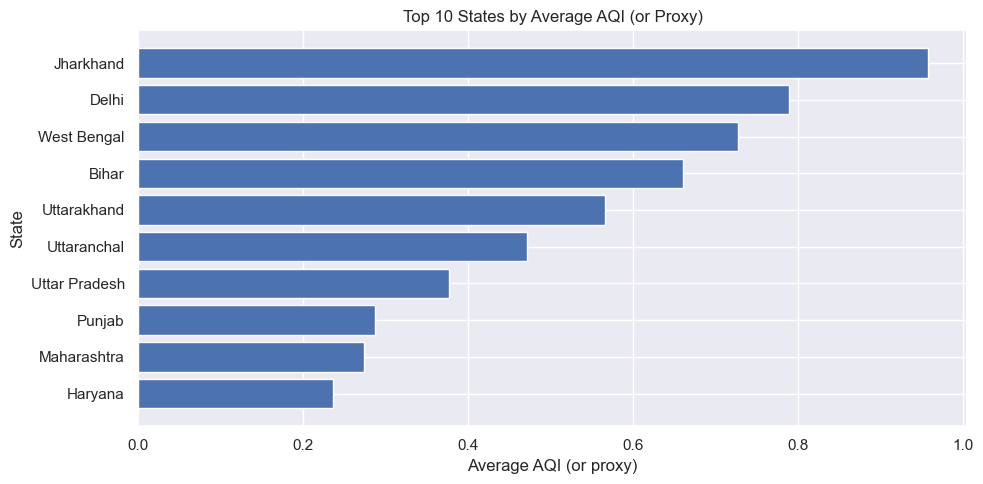

In [18]:
# Define the missing function
def display_dataframe_to_user(title, df):
    """
    Display a dataframe with a title to the user
    
    Parameters:
    title (str): The title to display above the dataframe
    df (pandas.DataFrame): The dataframe to display
    """
    print(title)
    display(df)  # This assumes you're in a Jupyter notebook environment

# a) Top 10 states by average AQI (or proxy)
top_states = None
if state_col is not None and aqi_effective_col is not None:
    top_states = safe_group_mean([state_col], aqi_effective_col)
    if top_states is not None:
        top_states_10 = top_states.head(10).copy()
        display_dataframe_to_user("Top 10 states — average AQI (or proxy)", top_states_10)
        # Plot
        plt.figure(figsize=(10, 5))
        plt.barh(top_states_10[state_col][::-1], top_states_10[aqi_effective_col][::-1])
        plt.title("Top 10 States by Average AQI (or Proxy)")
        plt.xlabel("Average AQI (or proxy)")
        plt.ylabel("State")
        plt.tight_layout()
        plt.show()

Yearly average AQI (or proxy)


,year,aqi_proxy
8,1995,0.835482
7,1994,0.675633
1,1988,0.631820
6,1993,0.612823
0,1987,0.567165
10,1997,0.489189
12,1999,0.467242
2,1989,0.461570
9,1996,0.461251
11,1998,0.417466


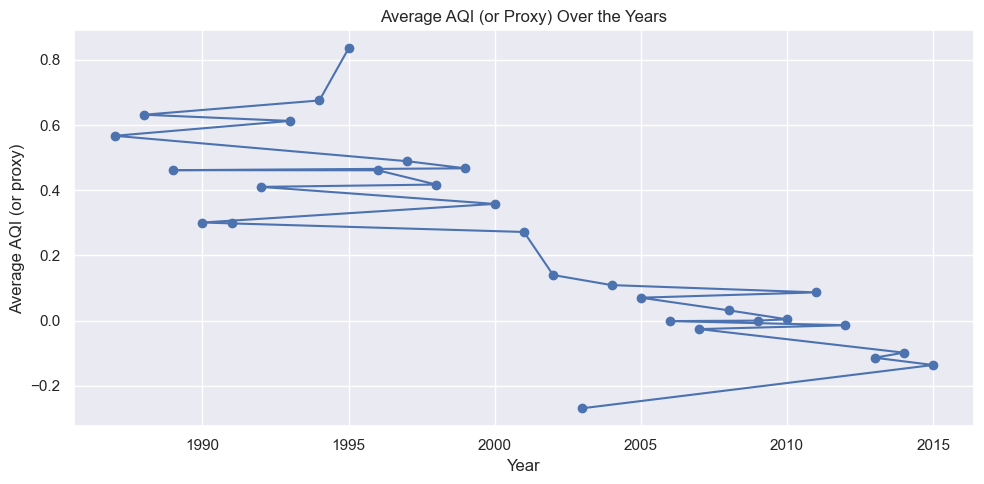

In [19]:
# b) Yearly trend in AQI (or proxy)
yearly_trend = None
if date_col is not None and aqi_effective_col is not None:
    yearly_trend = safe_group_mean(["year"], aqi_effective_col)
    if yearly_trend is not None and not yearly_trend.empty:
        display_dataframe_to_user("Yearly average AQI (or proxy)", yearly_trend)
        plt.figure(figsize=(10, 5))
        plt.plot(yearly_trend["year"], yearly_trend[aqi_effective_col], marker="o")
        plt.title("Average AQI (or Proxy) Over the Years")
        plt.xlabel("Year")
        plt.ylabel("Average AQI (or proxy)")
        plt.tight_layout()
        plt.show()

In [20]:
# c) City distribution (box-like summary via quantiles since pure boxplot may fail on sparse)
if state_col is not None and aqi_effective_col is not None:
    # Compute per-state quantiles to summarize distribution without seaborn
    state_quant = (
        df.dropna(subset=[aqi_effective_col])
          .groupby(state_col)[aqi_effective_col]
          .quantile([0.25, 0.5, 0.75])
          .unstack()
          .rename(columns={0.25: "q25", 0.5: "median", 0.75: "q75"})
          .sort_values("median", ascending=False)
    )
    top_states_for_dist = state_quant.head(12).copy()
    display_dataframe_to_user("Per-state AQI distribution summary (q25/median/q75)", top_states_for_dist)


Per-state AQI distribution summary (q25/median/q75)


,q25,median,q75
state,,,
Jharkhand,0.585214,0.901487,1.390251
Delhi,0.147197,0.583960,1.203512
Uttarakhand,0.269350,0.532281,0.788399
Uttaranchal,0.333700,0.469534,0.645943
West Bengal,-0.041989,0.443359,1.148865
Uttar Pradesh,0.024809,0.322614,0.633354
Bihar,-0.163510,0.299751,1.350781
Punjab,-0.135381,0.288223,0.619312
Haryana,-0.185194,0.181059,0.572438


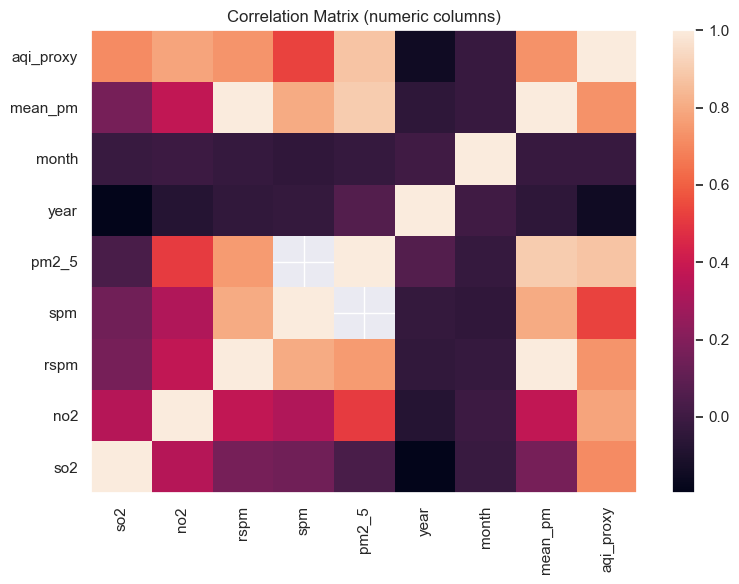

In [21]:
# -------------------------
# 7) CORRELATION (ONLY IF NUMERIC COLS ENOUGH)
# -------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr()
    # show a small correlation heatmap using matplotlib pcolormesh
    plt.figure(figsize=(8, 6))
    # convert to values
    cax = plt.pcolormesh(corr.values)
    plt.title("Correlation Matrix (numeric columns)")
    plt.xticks(np.arange(0.5, len(corr.columns), 1), corr.columns, rotation=90)
    plt.yticks(np.arange(0.5, len(corr.index), 1), corr.index)
    plt.colorbar(cax)
    plt.tight_layout()
    plt.show()

In [22]:
# -------------------------
# 8) SAVE CLEANED OUTPUT
# -------------------------
# Persist a curated subset useful for further modeling/visualization
keep_cols = set()
for c in [date_col, state_col, city_col, "year", "month", "mean_pm", aqi_effective_col]:
    if c is not None and c in df.columns:
        keep_cols.add(c)
# Also include raw pollutant columns that exist
for col in pollutant_cols.values():
    if col is not None and col in df.columns:
        keep_cols.add(col)

clean_df = df[list(keep_cols)].copy()
clean_df.to_csv(CLEAN_OUT, index=False)

# Display a preview of the cleaned file
display_dataframe_to_user("Cleaned AQI dataset preview", clean_df.head(25))

print(f"✅ Cleaned dataset saved to: {CLEAN_OUT}")
print("If you need additional plots or modeling, tell me which angle (policy impact, seasonality, forecasting, etc.).")


Cleaned AQI dataset preview


,mean_pm,date,location,rspm,no2,pm2_5,year,month,state,so2,aqi_proxy
0,NaN,1990-02-01,Hyderabad,NaN,17.4,NaN,1990,2,Andhra Pradesh,4.8,-0.496969
1,NaN,1990-02-01,Hyderabad,NaN,7.0,NaN,1990,2,Andhra Pradesh,3.1,-0.854051
2,NaN,1990-02-01,Hyderabad,NaN,28.5,NaN,1990,2,Andhra Pradesh,6.2,-0.134392
3,NaN,1990-03-01,Hyderabad,NaN,14.7,NaN,1990,3,Andhra Pradesh,6.3,-0.502829
4,NaN,1990-03-01,Hyderabad,NaN,7.5,NaN,1990,3,Andhra Pradesh,4.7,-0.768965
5,NaN,1990-03-01,Hyderabad,NaN,25.7,NaN,1990,3,Andhra Pradesh,6.4,-0.201108
6,NaN,1990-04-01,Hyderabad,NaN,17.1,NaN,1990,4,Andhra Pradesh,5.4,-0.478236
7,NaN,1990-04-01,Hyderabad,NaN,8.7,NaN,1990,4,Andhra Pradesh,4.7,-0.736538
8,NaN,1990-04-01,Hyderabad,NaN,23.0,NaN,1990,4,Andhra Pradesh,4.2,-0.372484
9,NaN,1990-05-01,Hyderabad,NaN,8.9,NaN,1990,5,Andhra Pradesh,4.0,-0.762447


✅ Cleaned dataset saved to: aqi_cleaned.csv
If you need additional plots or modeling, tell me which angle (policy impact, seasonality, forecasting, etc.).


In [27]:
# ========================
# Load & Clean Data
# ========================
# Try different encodings to handle special characters
try:
    # First attempt with default encoding
    df = pd.read_csv(DATA_PATH)
except UnicodeDecodeError:
    # If that fails, try with a more permissive encoding
    df = pd.read_csv(DATA_PATH, encoding='latin1')  # or try 'cp1252', 'ISO-8859-1'

df.columns = [c.strip().lower().replace(" ", "_").replace("/", "_") for c in df.columns]

# Identify columns
date_col = next((c for c in df.columns if "date" in c), None)
state_col = next((c for c in df.columns if "state" in c), None)
city_col = next((c for c in df.columns if "city" in c or "location" in c or "area" in c), None)
aqi_col = next((c for c in df.columns if "aqi" in c), None)

# Convert date
if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

# Basic cleaning
df = df.drop_duplicates()
for c in df.select_dtypes(include=["object"]).columns:
    df[c] = df[c].astype(str).str.strip()

# Numeric pollutants
pollutants = ["pm2_5", "pm25", "pm10", "no2", "so2", "o3", "co", "nh3"]
for c in pollutants:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Fallback AQI proxy
if not aqi_col:
    available = [c for c in pollutants if c in df.columns]
    df["aqi_proxy"] = df[available].mean(axis=1)
    aqi_col = "aqi_proxy"

# Add Year/Month
if date_col:
    df["year"] = df[date_col].dt.year
    df["month"] = df[date_col].dt.month

# Save cleaned with consistent encoding
df.to_csv(CLEAN_OUT, index=False, encoding='utf-8')
print(f"✅ Cleaned dataset saved as {CLEAN_OUT}")

/var/folders/5l/1dxt54xd5dn9fs97lbsrm2ch0000gp/T/ipykernel_8670/333045804.py:10: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH, encoding='latin1')  # or try 'cp1252', 'ISO-8859-1'
/var/folders/5l/1dxt54xd5dn9fs97lbsrm2ch0000gp/T/ipykernel_8670/333045804.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce")


✅ Cleaned dataset saved as aqi_cleaned.csv


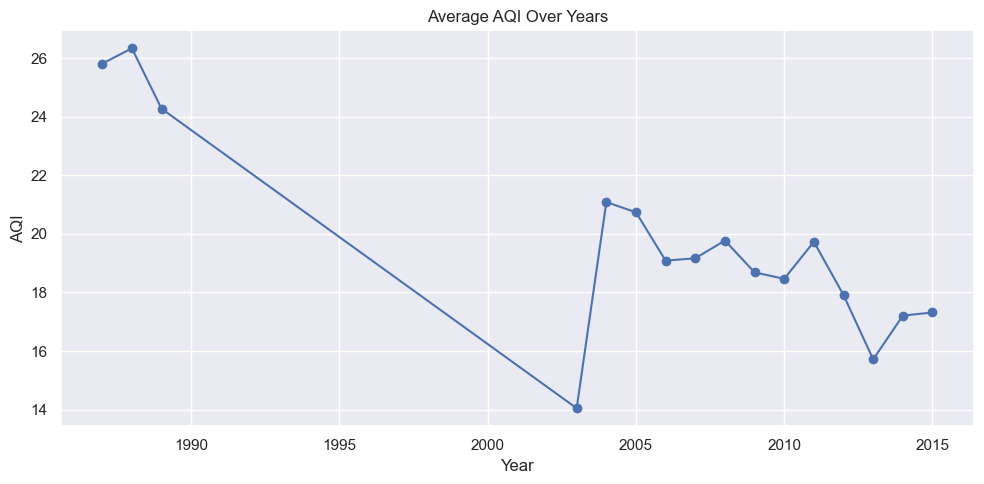

In [28]:
# ========================
# Exploratory Analysis
# ========================
plt.figure(figsize=(10, 5))
df.groupby("year")[aqi_col].mean().plot(marker='o')
plt.title("Average AQI Over Years")
plt.xlabel("Year")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()



RandomForest Results:
R2 Score: 0.9973511078612058
MAE: 0.23239853704566804


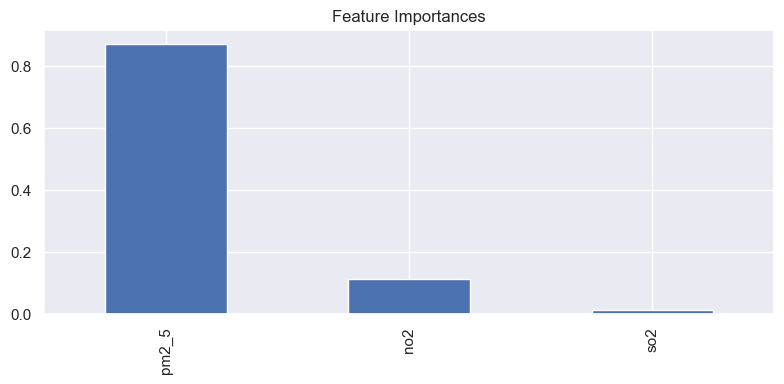

In [29]:
# ========================
# Random Forest Model
# ========================
X_cols = [c for c in pollutants if c in df.columns]
mdl = df.dropna(subset=[aqi_col] + X_cols)

X = mdl[X_cols]
y = mdl[aqi_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

print("\nRandomForest Results:")
print("R2 Score:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))

plt.figure(figsize=(8, 4))
importances = pd.Series(rf.feature_importances_, index=X_cols).sort_values(ascending=False)
importances.plot(kind="bar")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_pre

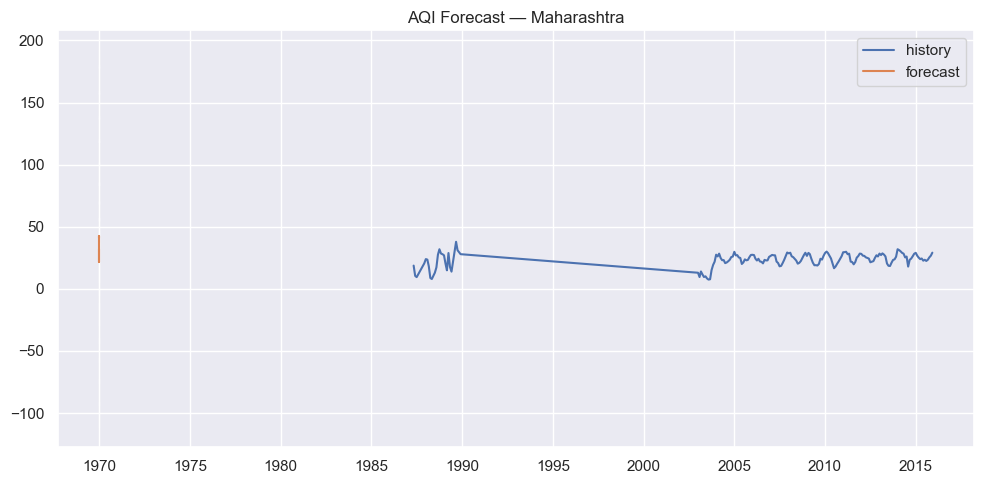

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_pre

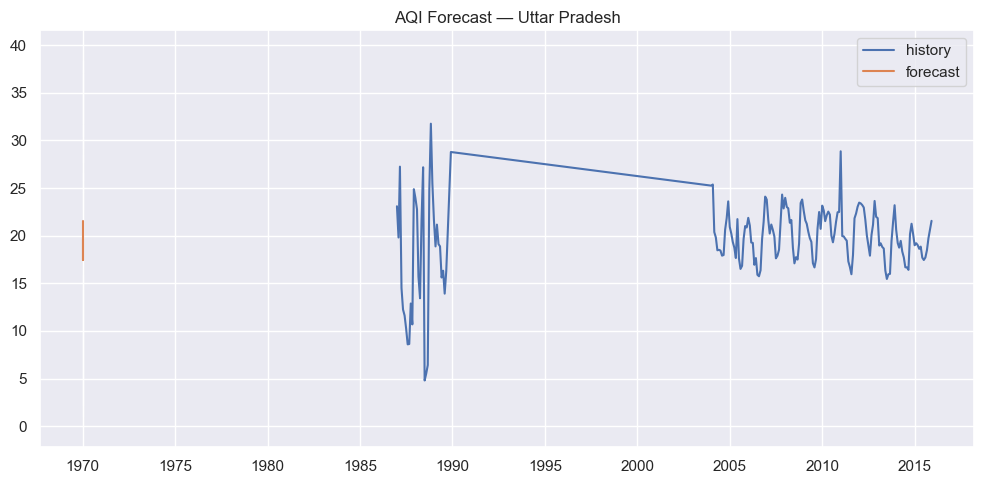

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_pre

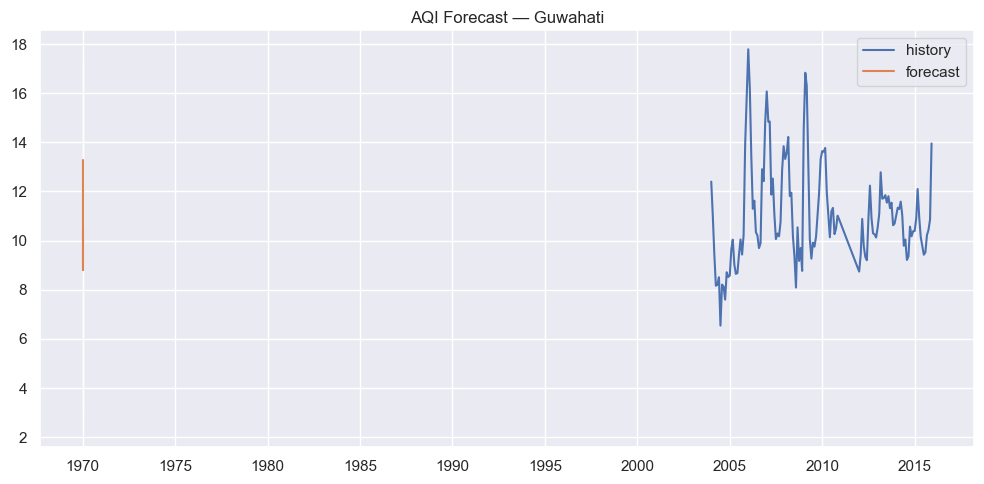

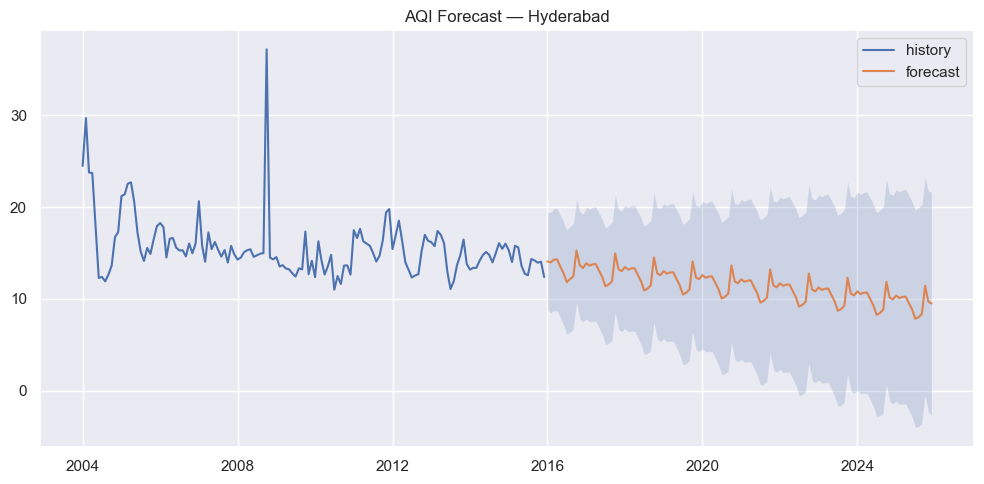

✅ Advanced analytics and 10-year forecasting completed successfully.


In [30]:
# ========================
# Time-Series Forecasting
# ========================

def monthly_avg(df, date_col, val_col):
    s = df.dropna(subset=[date_col, val_col]).set_index(date_col)[val_col].resample("MS").mean().dropna()
    return s

def forecast_series(y, steps=120):
    model = SARIMAX(y, order=(1,1,1), seasonal_order=(1,1,1,12),
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    fc = res.get_forecast(steps=steps)
    f_mean = fc.predicted_mean
    f_ci = fc.conf_int()
    out = pd.DataFrame({"history": y, "forecast": f_mean,
                        "lower": f_ci.iloc[:,0], "upper": f_ci.iloc[:,1]})
    return out

# Forecast for top states/cities
if date_col and state_col:
    top_states = df[state_col].value_counts().head(2).index
    for st in top_states:
        y = monthly_avg(df[df[state_col]==st], date_col, aqi_col)
        if len(y) > 36:
            fc = forecast_series(y)
            plt.figure(figsize=(10,5))
            plt.plot(y.index, y.values, label="history")
            plt.plot(fc["forecast"].index, fc["forecast"].values, label="forecast")
            plt.fill_between(fc.index, fc["lower"], fc["upper"], alpha=0.2)
            plt.title(f"AQI Forecast — {st}")
            plt.legend()
            plt.tight_layout()
            plt.show()

if date_col and city_col:
    top_cities = df[city_col].value_counts().head(2).index
    for ct in top_cities:
        y = monthly_avg(df[df[city_col]==ct], date_col, aqi_col)
        if len(y) > 36:
            fc = forecast_series(y)
            plt.figure(figsize=(10,5))
            plt.plot(y.index, y.values, label="history")
            plt.plot(fc["forecast"].index, fc["forecast"].values, label="forecast")
            plt.fill_between(fc.index, fc["lower"], fc["upper"], alpha=0.2)
            plt.title(f"AQI Forecast — {ct}")
            plt.legend()
            plt.tight_layout()
            plt.show()

print("✅ Advanced analytics and 10-year forecasting completed successfully.")